# ViEVOLVEdi

In [ ]:
# Core libraries
import os

# MIDI and MusicXML handling
from music21 import converter, environment

# Plotly configuration
import plotly.io as pio
pio.renderers.default = "jupyterlab"

# MetaZoo 
from metazoo.bio.evolutionary import GeneticAlgorithm
from metazoo.bio.evolutionary.operators import selection
from metazoo.bio.utils import Population

# Utils 

from melody_encoding import MelodyEncoding
from utils import melody_to_midi
from fitness import ScoreFitness
from operators import MelodyOperators

In [2]:
# MIDI and MusicXML settings

us = environment.UserSettings()
us['musicxmlPath'] = '/Applications/MuseScore 4.app/Contents/MacOS/mscore'
us['musescoreDirectPNGPath'] = '/Applications/MuseScore 4.app/Contents/MacOS/mscore'
# Save Path
SAVE_PATH = os.path.join(os.getcwd(), "generated")
os.makedirs(SAVE_PATH, exist_ok=True)

In [3]:
encoding = MelodyEncoding(note_range=(60, 72), length=16)
population = Population(population_size=100, encoding=encoding)

In [4]:
population.individuals[0]

array([[ 0.  ,  2.  ],
       [ 0.  ,  2.  ],
       [64.  ,  1.  ],
       [60.  ,  0.5 ],
       [71.  ,  2.  ],
       [ 0.  ,  2.  ],
       [70.  ,  0.5 ],
       [62.  ,  0.5 ],
       [63.  ,  1.  ],
       [62.  ,  0.25],
       [63.  ,  0.5 ],
       [66.  ,  0.5 ],
       [70.  ,  0.5 ],
       [64.  ,  1.  ],
       [66.  ,  2.  ],
       [65.  ,  0.25]])

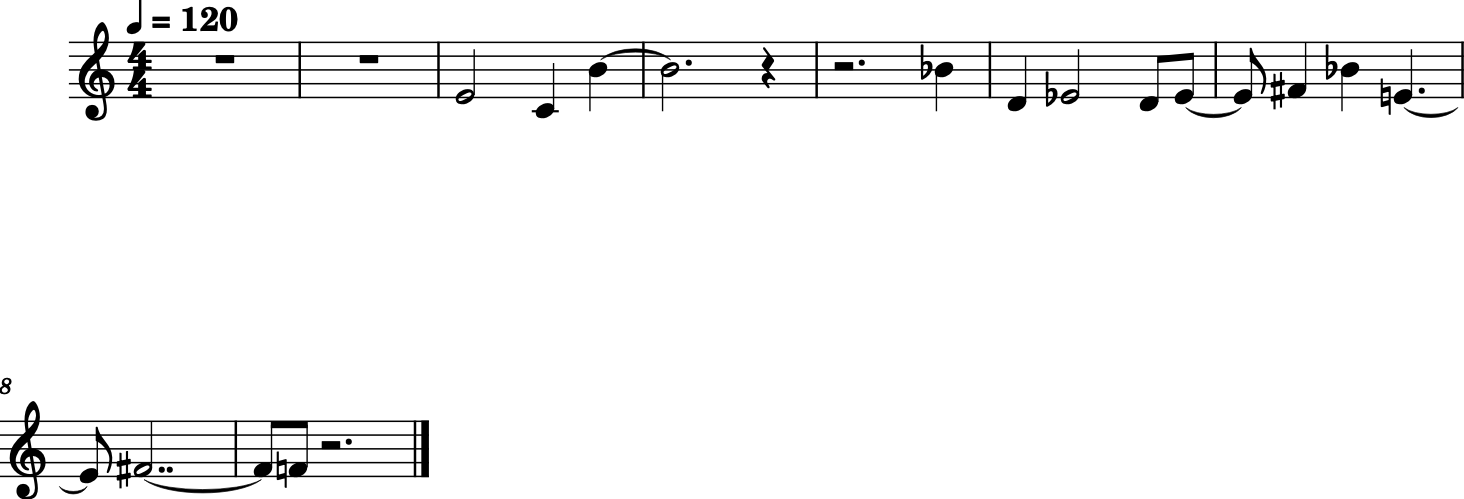

In [ ]:
melody = population.individuals[0]
midi_file = melody_to_midi(melody)
score = converter.parse(midi_file)
score.show()
# delete melody.mid file
os.remove("melody.mid")

# Fitness

In [6]:
fitness = ScoreFitness()
fitness.plot(melody)

## Operators

In [8]:
class MelodyGA(GeneticAlgorithm):
    def __init__(self, *args, **kwargs):
        kwargs['minimize'] = False
        super().__init__(*args, **kwargs)

## Genetic Algorithm

In [9]:
ga = MelodyGA(
    fitness_function=fitness.fitness_function,
    selection_function=selection.tournament,
    crossover_function=MelodyOperators.crossover,
    mutation_function=MelodyOperators.mutation,
    crossover_rate=0.7,
    mutation_rate=0.1,
    encoder=MelodyEncoding(note_range=(60, 72), length=128),
    elitism=0.1
)

In [ ]:
ga.run(generations=500)

Output()

In [ ]:
ga.fitness_plot()

In [ ]:
ga.best_individual.shape

(128, 2)

MIDI file saved to: /Users/roicort/GitHub/MetaZoo/playgrounds/viEvolvedi/generated/melody_01-12-25, 12.30.mid


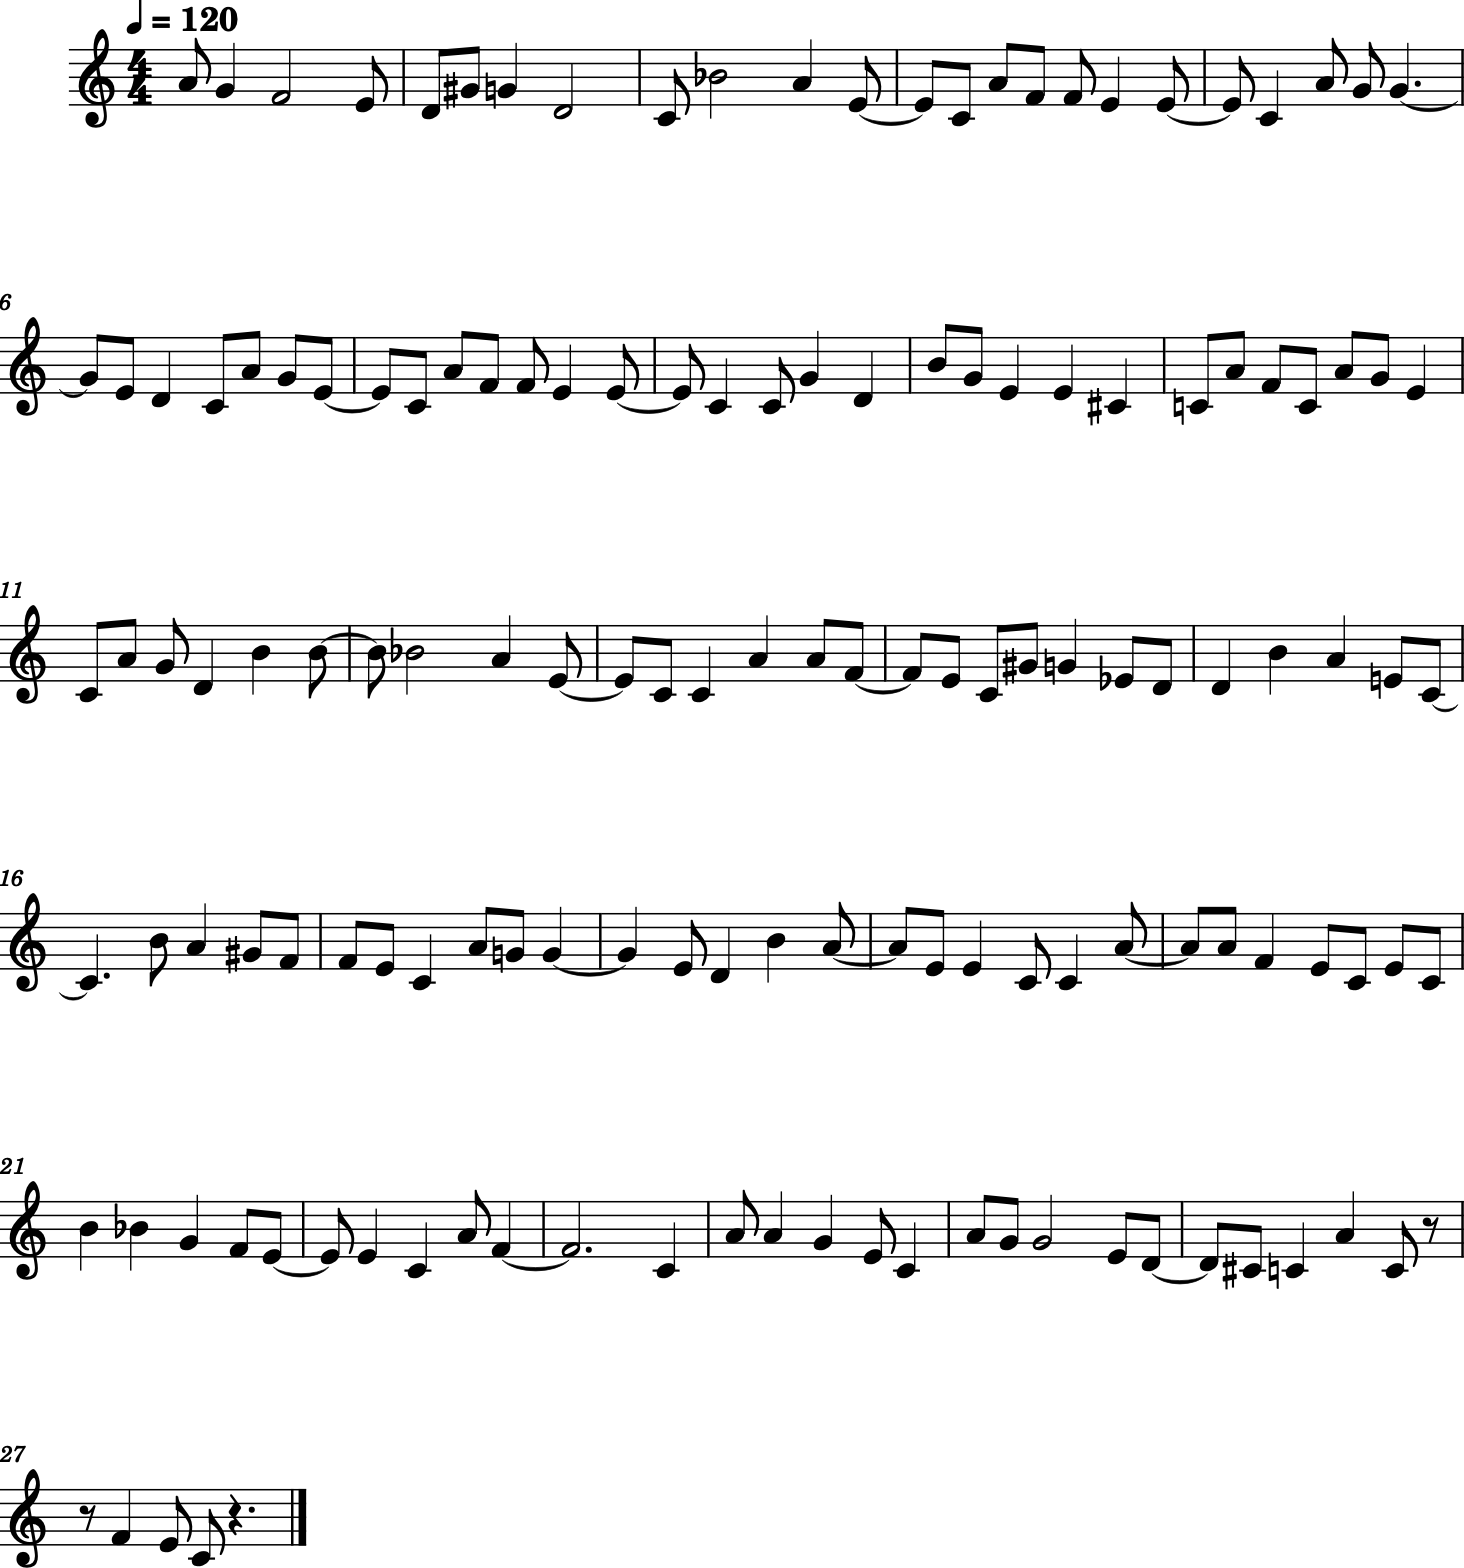

In [ ]:
from datetime import datetime

melody = ga.best_individual
date = datetime.now().strftime("%d-%m-%y, %H.%M")
midi_path = os.path.join(SAVE_PATH, f"melody_{date}.mid")
midi_file = melody_to_midi(melody, filename=midi_path)
print(f"MIDI file saved to: {midi_path}")
score = converter.parse(midi_file)
score.show()

In [ ]:
fitness.plot(melody)